# Feature Neutralization (Нейтрализация признаков)

Одна из вещей, которая затрудняет предсказание фондового рынка, заключается в "нестационарной" связи между признаками и доходностью. Признаки могут обладать сильной прогностической способностью в некоторые периоды, но не в другие, либо полностью менять направление со временем.

Эта неопределенность называется `Feature Risk`. Чтобы создать модели с постоянной производительностью, полезно снизить этот риск посредством `Feature Neutralization`. В данном руководстве мы рассмотрим:

1. Как количественно оценить риск признака.
2. Измерение подверженности модели влиянию признаков.
3. Применение нейтрализации признаков к прогнозам.
4. Оценка производительности нейтрализованных прогнозов.
5. Сохранение и загрузка модели, свободной от влияния признаков.

In [ ]:
# Install dependencies (Запускать 2 раза, первый с ошибкой)
!pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle
!pip install -q --no-deps numerai-tools

# Inline plots
%matplotlib inline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta
import time

from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution, neutralize


import json
import os
import gc
import shutil

import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import make_scorer
import cloudpickle

import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_columns = 500

# 1. Feature Risk  

Чтобы количественно оценить `Feature Risk`, необходимо оценить производительность каждого признака отдельно.

## Feature Groups
Есть восемь групп признаков:  
- intelligence («интеллект»)
- wisdom («мудрость)
- charisma(«харизма»)
- dexterity(«ловкость»)
- strength («сила)
- constitution («конституция»)
- agility («проворство»)
- serenity («спокойствие»)
- midnight
- rain
- sunshine
- v2_equivalent_features
- v3_equivalent_features
- fncv3_features
  
Каждая группа включает признаки разного типа. Например, все технические сигналы будут находиться в одной группе, тогда как прогнозы и оценки аналитиков — в другой.

Группы признаков в `small`, `medium` и `all` в наборах признаков:

In [2]:
# initialize our API client
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

napi.download_dataset(f"{DATA_VERSION}/features.json")
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

sizes = ["small", "medium", "all"]
groups = [x for x in feature_sets if x not in sizes[:2]] # if x not in sizes

# compile the intersections of feature sets and feature groups
subgroups = {}
for size in sizes:
    subgroups[size] = {}
    for group in groups:
        subgroups[size][group] = (
            set(feature_sets[size])
            .intersection(set(feature_sets[group]))
        )

# convert to data frame and display the feature count of each intersection
pd.DataFrame(subgroups).applymap(len).sort_values(by="all", ascending=False)

v5.0/features.json: 291kB [00:00, 2.26MB/s]                           


,small,medium,all
all,42,705,2376
v3_equivalent_features,15,400,1000
rain,20,0,666
fncv3_features,8,400,400
constitution,2,134,335
sunshine,5,130,325
v2_equivalent_features,7,304,304
charisma,3,116,290
midnight,0,122,244
agility,2,58,145


Для данного руководства мы собираемся проанализировать признаки группы serenity из набора small.

Мы читаем весь тренировочный набор признаков small, чтобы позже обучиться на нём:

In [3]:
feature_size = "small"

small_features = feature_sets[feature_size]
sm_serenity_feats = list(subgroups[feature_size]["serenity"])

napi.download_dataset(f"{DATA_VERSION}/train.parquet")

train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + small_features
)

v5.0/train.parquet: 2.37GB [01:24, 28.0MB/s]                            


### Evaluating feature performance (Оценка эффективности признаков)

Рассматривая риск признаков, первым делом стоит проверить корреляцию каждого признака с целевой переменной на обучающем датасете. Это позволит нам определить характер взаимосвязи каждого признака с целью:

<Axes: title={'center': 'Cumulative Absolute Value CORR of Features and the Target'}, xlabel='Era'>

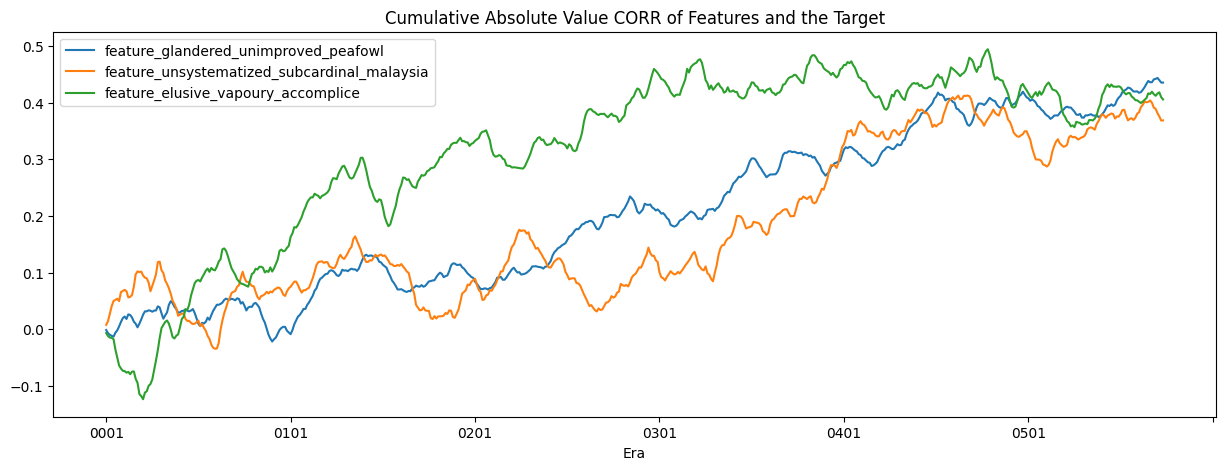

In [4]:
# Compute the per-era correlation of each serenity feature to the target
per_era_corr = train.groupby("era").apply(
    lambda d: numerai_corr(d[sm_serenity_feats], d["target"])
)

# Flip sign for negative mean correlation since we only care about magnitude
per_era_corr *= np.sign(per_era_corr.mean())

# Plot the per-era correlations
per_era_corr.cumsum().plot(
    title="Cumulative Absolute Value CORR of Features and the Target",
    figsize=(15, 5),
    legend=True,
    xlabel="Era"
  )

Посчитаем некоторые сводные показатели производительности.

Обратите внимание, что выше видно, как некоторые признаки могут демонстрировать совершенно разные характеристики в разное время периода проверки. Для измерения степени изменения производительности признака на протяжении всего периода анализа введём новый показатель:

`Delta` — это абсолютная разница средней корреляции между первой и второй половиной периода анализа.

In [5]:
def metrics(corr):
    corr_mean = corr.mean()
    corr_std = corr.std(ddof=0)
    corr_sharpe = corr_mean / corr_std
    max_drawdown = -(corr.cumsum().expanding(min_periods=1).max() - corr.cumsum()).max()

    eras = train.era.unique()
    halfway_era = len(eras)//2
    corr_mean_first_half = corr.loc[eras[:halfway_era]].mean()
    corr_mean_second_half = corr.loc[eras[halfway_era:]].mean()
    delta = abs(corr_mean_first_half - corr_mean_second_half)

    return {
      "mean": corr_mean,
      "std": corr_std,
      "sharpe": corr_sharpe,
      "max_drawdown": max_drawdown,
      "delta": delta
    }

# compute performance metrics for each feature
feature_metrics = [
    metrics(per_era_corr[feature_name])
    for feature_name in sm_serenity_feats
]

# convert to numeric DataFrame and sort
feature_metrics = (
    pd.DataFrame(feature_metrics, index=sm_serenity_feats)
    .apply(pd.to_numeric)
    .sort_values("mean", ascending=False)
)

feature_metrics

,mean,std,sharpe,max_drawdown,delta
feature_glandered_unimproved_peafowl,0.0008,0.0045,0.1696,-0.0762,0.0001
feature_elusive_vapoury_accomplice,0.0007,0.0069,0.1031,-0.1375,0.0014
feature_unsystematized_subcardinal_malaysia,0.0006,0.0067,0.0961,-0.1537,0.0006


Просмотрев приведённые ниже визуализации, наиболее очевидным наблюдением является сильная корреляция между показателями `mean` и `sharpe`. Это неудивительно, учитывая, что `Sharpe Ratio` — это отношение среднего значения (mean) к стандартному отклонению (std).

Более интересным наблюдением является тот факт, что среднее значение (mean) слабо связано с такими метриками риска, как стандартное отклонение (std), максимальный спад (max_drawdown) и дельта (delta). Это ясно показывает, что высокая средняя производительность признака вовсе не гарантирует стабильность или низкий уровень риска.

В следующем разделе мы подробнее изучим стандартные отклонения (std), максимальные просадки (max_drawdown) и дельту (delta), чтобы лучше понять риски признаков.

array([[<Axes: title={'center': 'mean'}>,
        <Axes: title={'center': 'std'}>,
        <Axes: title={'center': 'sharpe'}>],
       [<Axes: title={'center': 'max_drawdown'}>,
        <Axes: title={'center': 'delta'}>, <Axes: >]], dtype=object)

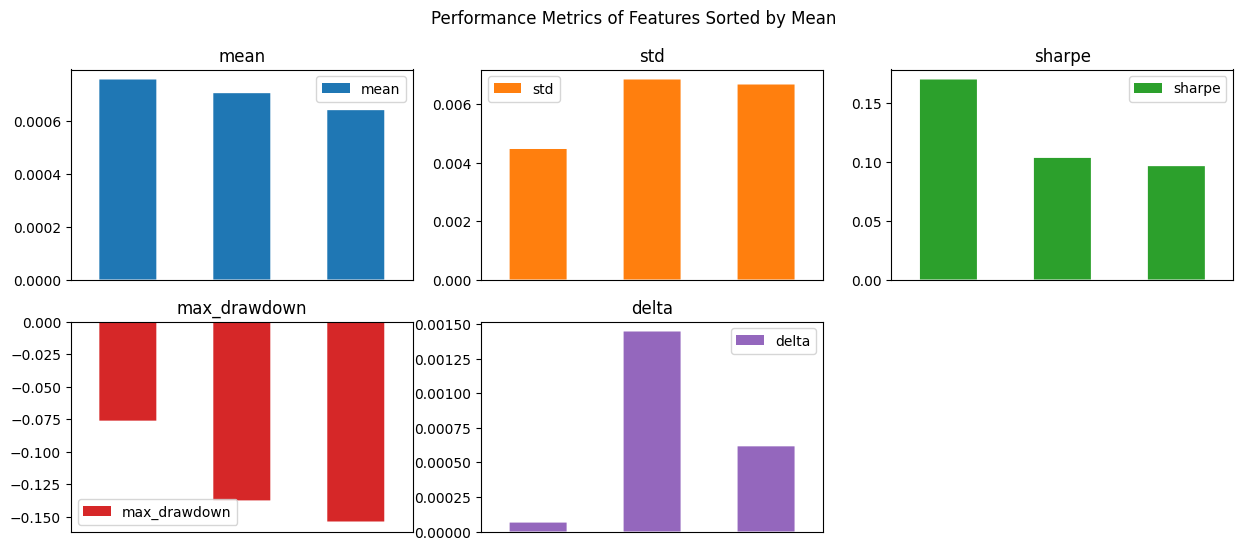

In [6]:
# plot the performance metrics of the features as bar charts sorted by mean
feature_metrics.sort_values("mean", ascending=False).plot.bar(
    title="Performance Metrics of Features Sorted by Mean",
    subplots=True,
    figsize=(15, 6),
    layout=(2, 3),
    sharex=False,
    xticks=[],
    snap=False
)

### Comparing feature risk (Сравнение рисков признаков)  

Ниже представлено сравнение производительности признаков с наибольшими и наименьшими значениями стандартного отклонения (std). Какой признак выглядит для вас более рискованным и почему?

Можно утверждать, что оранжевая линия кажется более рискованной благодаря резким и значительным изменениям направлений. Экстраполируя вперёд, можно ожидать продолжения подобной волатильности вне выборки.

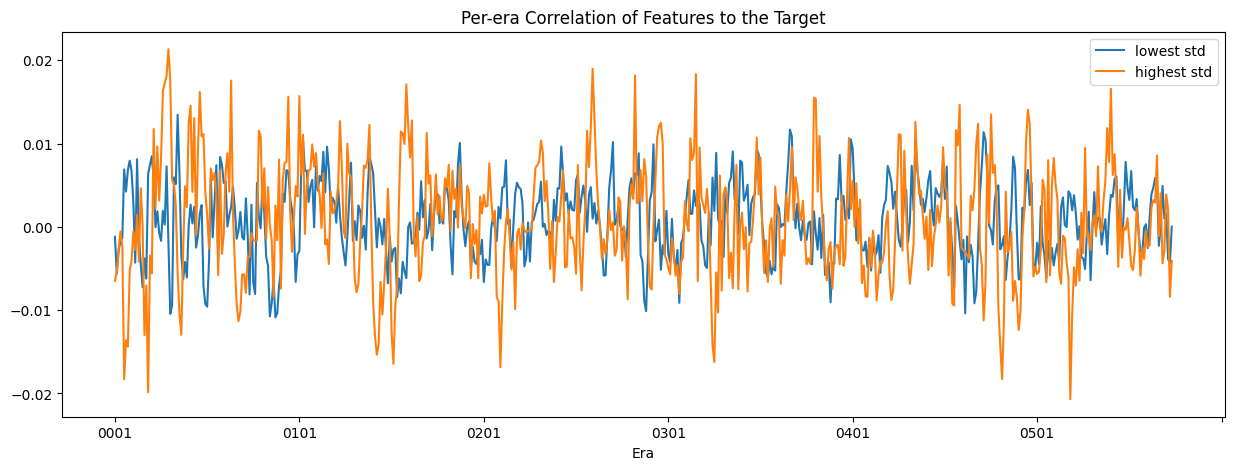

In [7]:
# plot the per era correlation of the feature with the highest vs lowest std
per_era_corr[[feature_metrics["std"].idxmin(), feature_metrics["std"].idxmax()]].plot(
    figsize=(15, 5), title="Per-era Correlation of Features to the Target", xlabel="Era"
)
plt.legend(["lowest std", "highest std"])

Ниже приводится сравнение признаков с наивысшим и наименьшим показателем `delta`. Какой признак кажется вам более рискованным и почему?

Можно сказать, что оранжевая линия выглядит более рискованно из-за полного разворота производительности между первой и второй половинами периода, несмотря на то, что обе линии заканчивают примерно одинаково. Продолжая экстраполяцию вперед, можно предположить, что эта характеристика перестанет работать вообще вне выборки.

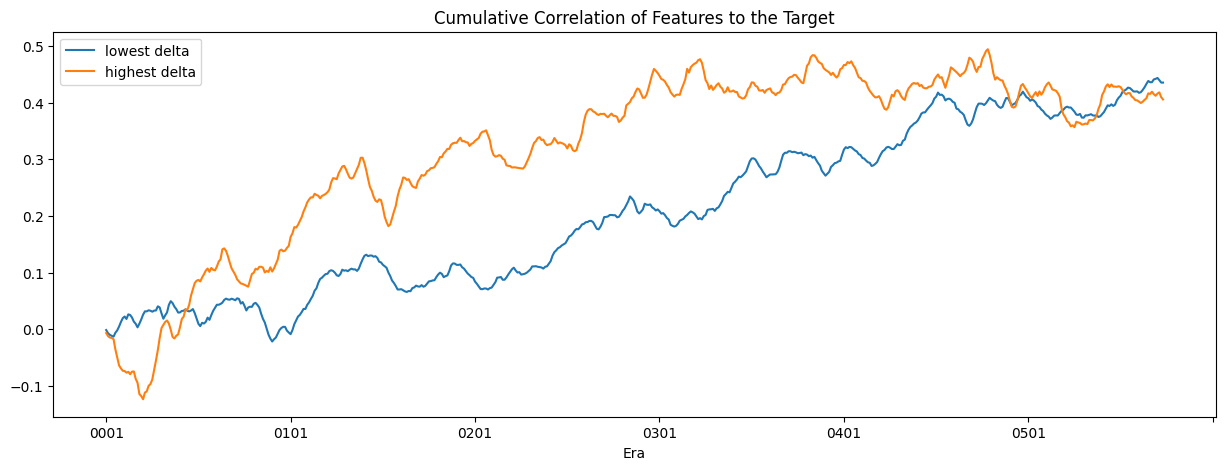

In [8]:
# plot the cumulative per era correlation of the feature with the highest vs lowest delta
per_era_corr[[feature_metrics["delta"].idxmin(), feature_metrics["delta"].idxmax()]].cumsum().plot(
    figsize=(15, 5), title="Cumulative Correlation of Features to the Target", xlabel="Era"
)
plt.legend(["lowest delta", "highest delta"])

Приведено сравнение признаков с наибольшим и наименьшим значением показателя максимального спада (`max_drawdown`). Какой признак кажется вам более рискованным и почему?

Можно считать, что оранжевая линия выглядит более рискованной из-за огромного спада в середине, хотя обе линии завершаются примерно одинаково. Экстраполируя дальше, можно ожидать ещё одного большого спада вне выборки.

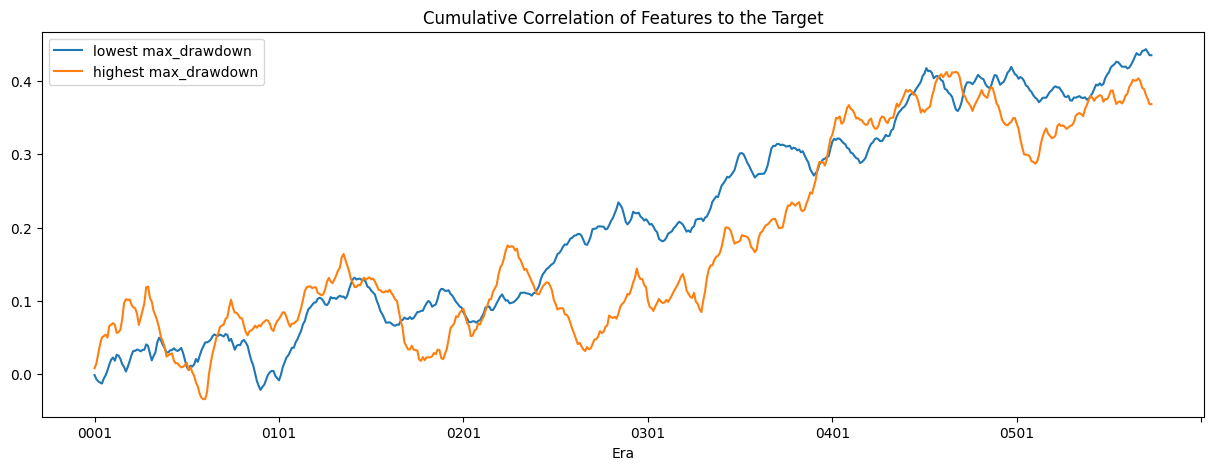

In [9]:
# plot the cumulative per era correlation of the feature with the highest vs lowest max_drawdown
per_era_corr[[feature_metrics["max_drawdown"].idxmax(), feature_metrics["max_drawdown"].idxmin()]].cumsum().plot(
    figsize=(15, 5), title="Cumulative Correlation of Features to the Target", xlabel="Era"
)
plt.legend(["lowest max_drawdown", "highest max_drawdown"])

Метрики, проанализированные выше, являются лишь несколькими способами количественного выражения риска признаков среди множества возможных подходов.

Какие ещё способы измерения риска признаков вы можете предложить?

Подумайте над этим вопросом, пока мы обучаем модель на всём малом наборе признаков.

In [ ]:
model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    num_leaves=2**3-1,
    colsample_bytree=0.1
)

model.fit(train[small_features], train["target"]
)

## 2. Feature Exposure

**Feature exposure** (Подверженность признакам) — это мера чувствительности модели к риску отдельных признаков, рассчитываемая как коэффициент Пирсона между прогнозами модели и каждым признаком. Давайте загрузим и выполним прогнозирование на проверочных данных для нашего малого набора признаков.

In [11]:
# Download validation data
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")

# Load the validation data, filtering for data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + small_features
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Embargo overlapping eras from training data
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Generate predictions against the small feature set of the validation data
validation["prediction"] = model.predict(validation[small_features])

v5.0/validation.parquet: 3.57GB [00:55, 64.5MB/s]                            


### Visualizing feature exposures (Визуализация подверженности признакам)  
Как показано на графике ниже, наша модель постоянно демонстрирует сильную корреляцию с некоторыми признаками. Если эти признаки внезапно поменяют своё поведение или прекратят эффективно работать, наши прогнозы, вероятно, проявят аналогичные рискованные свойства, рассмотренные ранее.

Text(0.5, 0.98, 'Feature Exposures')

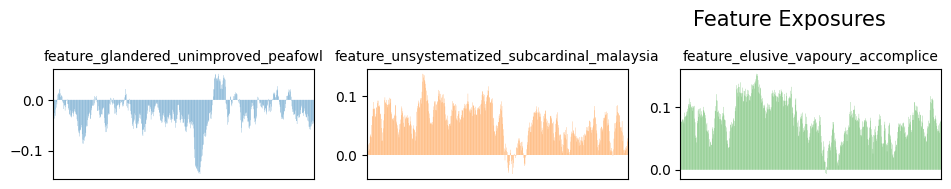

In [12]:
# Compute the Peason correlation of the predictions with each of the serenity features of the small feature set
feature_exposures = validation.groupby("era").apply(
    lambda d: d[sm_serenity_feats].corrwith(d["prediction"])
)

# Plot the feature exposures as bar charts
feature_exposures.plot.bar(
    title="Feature Exposures",
    figsize=(16, 10),
    layout=(7,5),
    xticks=[],
    subplots=True,
    sharex=False,
    legend=False,
    snap=False
)
for ax in plt.gcf().axes:
    ax.set_xlabel("")
    ax.title.set_fontsize(10)
plt.tight_layout(pad=1.5)
plt.gcf().suptitle("Feature Exposures", fontsize=15)

### Max Feature Exposure (Максимальная подверженность признакам)


Изучая представленные выше визуализации, обратите внимание на масштаб и постоянство изменений подверженности различным признакам.

Есть идеи, как сделать такую визуализацию более информативной?

Один из полезных способов представить общую подверженность нашей модели признакам — посмотреть на `max feature exposure` каждого признака по эпохам. Это простой способ приблизительно оценить максимальное воздействие любого отдельного признака на нашу модель в заданный момент времени.

Заметьте, что мы измеряем `feature exposure` только подмножества выбранных нами признаков для анализа.

Mean of max feature exposure 0.08112771163753954


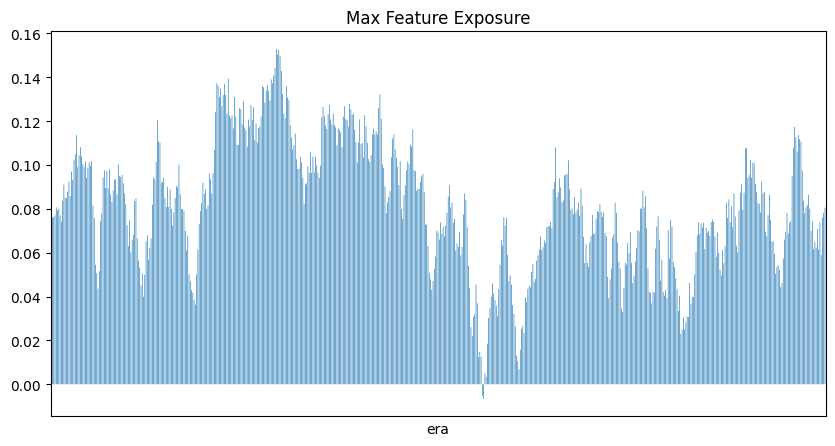

In [13]:
# Plot the max feature exposure per era
max_feature_exposure = feature_exposures.max(axis=1)
max_feature_exposure.plot(
  title="Max Feature Exposure",
  kind="bar",
  figsize=(10, 5),
  xticks=[],
  snap=False
)
# Mean max feature exposure across eras
print("Mean of max feature exposure", max_feature_exposure.mean())

## 3. Feature Neutralization (Нейтрализация признаков)


Очевидно, что модель имеет устойчивую `feature exposure`, на которых была обучена.

Нейтрализация признаков представляет собой метод снижения `feature exposure`.

По сути, нейтрализация по отношению к определённому признаку означает удаление той части ваших прогнозов (или сигнала), которая коррелирует с данным признаком, оставляя только уникальную остаточную компоненту сигнала.

Посты форума о математике, лежащей в основе нейтрализации признаков:
- https://forum.numer.ai/t/model-diagnostics-feature-exposure/899
- https://forum.numer.ai/t/an-introduction-to-feature-neutralization-exposure/4955

### Applying feature neutralization (Применение нейтрализации признаков)


Применим нейтрализацию признаков к нашим прогнозам в разных пропорциях и посмотрим, как это влияет на `max feature exposure`.

In [ ]:
# Neutralize predictions per-era against features at different proportions
proportions = [0.25, 0.5, 0.75, 1.0]
for proportion in proportions:
    neutralized = validation.groupby('era', group_keys=True).apply(
        lambda d: neutralize(
          d[['prediction']],
          d[sm_serenity_feats],
          proportion=proportion
        )
    ).reset_index().set_index('id')
    validation[f'neutralized_{proportion*100:.0f}'] = neutralized['prediction']

# Align the neutralized predictions with the validation data
prediction_cols = ['prediction'] + [f for f in validation.columns if 'neutralized' in f]
validation[['era', 'target'] + prediction_cols]

,era,target,prediction,neutralized_25,neutralized_50,neutralized_75,neutralized_100
id,,,,,,,
n0005339ce5e6cad,0578,0.5000,0.4974,0.3725,0.2476,0.1227,-0.0022
n001e265c6584874,0578,0.5000,0.5006,0.3756,0.2507,0.1257,0.0008
n0029194621a1a63,0578,0.5000,0.4998,0.3748,0.2499,0.1249,-0.0001
n0046736de1c970b,0578,1.0000,0.5014,0.3763,0.2513,0.1263,0.0013
n00505cd5d2350de,0578,0.5000,0.4942,0.3691,0.2440,0.1189,-0.0061
...,...,...,...,...,...,...,...
nffd6a9e3c644c35,1190,0.2500,0.5079,0.3829,0.2579,0.1329,0.0080
nffe74f5f036dea1,1190,0.2500,0.4986,0.3737,0.2487,0.1238,-0.0011
nffe75ecba7064bd,1190,0.2500,0.4969,0.3719,0.2468,0.1217,-0.0034


Видно, что по мере приближения пропорции нейтрализации к `1`, `feature exposure` стремится к нулю.

mean feature exposures:
prediction        0.0850
neutralized_25    0.0640
neutralized_50    0.0430
neutralized_75    0.0210
neutralized_100   0.0000
dtype: float64


<Axes: title={'center': 'Max Feature Exposures'}, xlabel='era'>

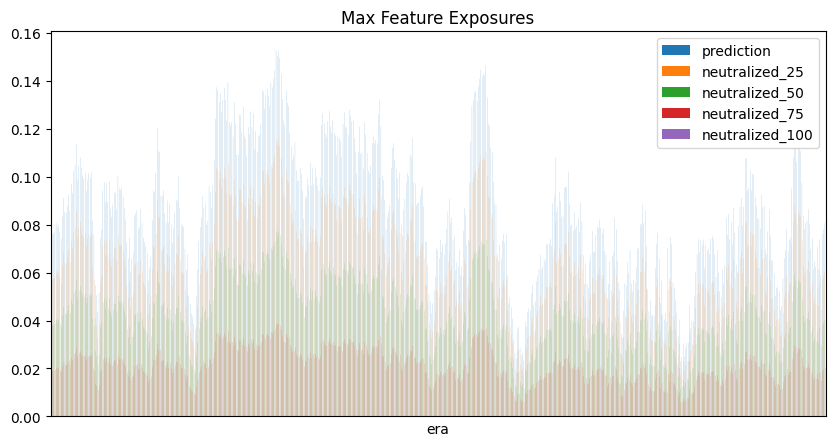

In [15]:
# Compute max feature exposure for each set of predictions
max_feature_exposures = pd.concat([
    validation.groupby("era").apply(
        lambda d: d[sm_serenity_feats].corrwith(d[col]).abs().max()
    ).rename(col)
    for col in prediction_cols
], axis=1)

# print mean feature exposure of each proportion
print('mean feature exposures:')
print(round(max_feature_exposures.mean(), 3))

# Plot max feature exposures
max_feature_exposures.plot.bar(
  title="Max Feature Exposures",
  figsize=(10, 5),
  xticks=[],
  snap=False
)


### Performance impact of neutralization (Влияние нейтрализации на производительность)  


Анализируя график производительности ниже, видим незначительное улучшение результатов по мере увеличения доли применённой нейтрализации, однако общая форма кривой остаётся практически неизменной.

Вы могли заметить, что иногда оптимальная доля нейтрализации за период проверки меньше единицы, что подразумевает полезность небольшого уровня `feature exposure`. Завершив данное руководство, продолжайте экспериментировать с различными долями нейтрализации и анализировать компромисс между снижением воздействия признаков и улучшением производительности.

<Axes: title={'center': 'Cumulative Correlation of Neutralized Predictions'}, xlabel='era'>

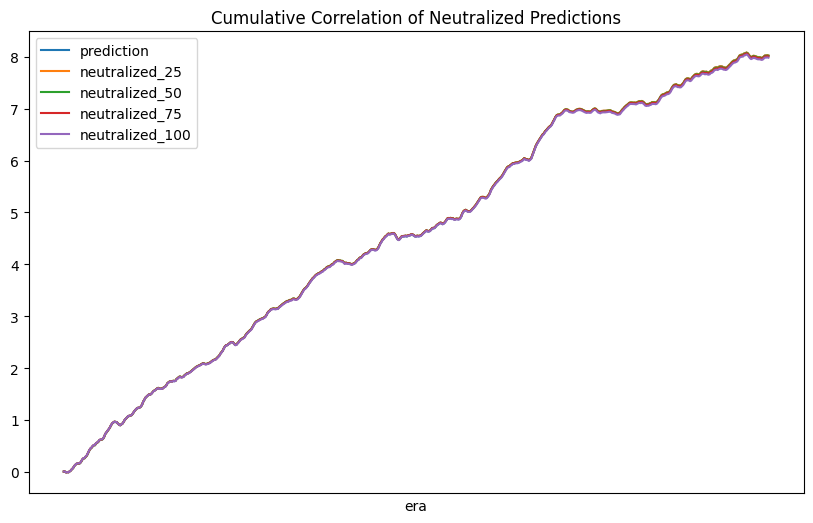

In [16]:
# calculate per-era CORR for each set of predictions
correlations = validation.groupby("era").apply(
    lambda d: numerai_corr(d[prediction_cols], d["target"])
)

# calculate the cumulative corr across eras for each neutralization proportion
cumulative_correlations = correlations.cumsum().sort_index()

# Show the cumulative correlations
pd.DataFrame(cumulative_correlations).plot(
    title="Cumulative Correlation of Neutralized Predictions",
    figsize=(10, 6),
    xticks=[]
)

Рассмотрим другие агрегированные метрики, такие как `mean`, `std`, `sharpe` и `max_drawdown`.

Какой вид зависимости вы видите между долей нейтрализации и общей производительностью?

In [17]:
summary_metrics = {}
for col in prediction_cols:
    mean = correlations[col].mean()
    std = correlations[col].std(ddof=0)
    sharpe = mean / std
    rolling_max = cumulative_correlations[col].expanding(min_periods=1).max()
    max_drawdown = (rolling_max - cumulative_correlations[col]).max()
    summary_metrics[col] = {
        "mean": mean,
        "std": std,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    }
pd.set_option('display.float_format', lambda x: '%f' % x)
pd.DataFrame(summary_metrics).T

,mean,std,sharpe,max_drawdown
prediction,0.013090,0.016556,0.790648,0.126650
neutralized_25,0.013093,0.016588,0.789308,0.126646
neutralized_50,0.013081,0.016610,0.787533,0.126626
neutralized_75,0.013061,0.016626,0.785559,0.126161
neutralized_100,0.013022,0.016633,0.782932,0.126384


### Neutralizing different groups (Нейтрализация различных групп признаков)  

Учитывая, что мы обучали нашу модель на полном наборе признаков `small`, неудивительно, что нейтрализация небольшого подмножества из 34 признаков оказывает минимальное влияние на производительность. Поэтому давайте повторим этот эксперимент, но теперь попробуем нейтрализовать каждую группу внутри набора `small`, поддерживая долю нейтрализации постоянной на уровне 100%.

Как видно из графика производительности ниже, нейтрализация по различным группам значительно сильнее сказывается на результатах, что вполне ожидаемо, поскольку эти группы принципиально отличаются друг от друга.


<Axes: title={'center': 'Cumulative Correlation of Neutralized Predictions'}, xlabel='era'>

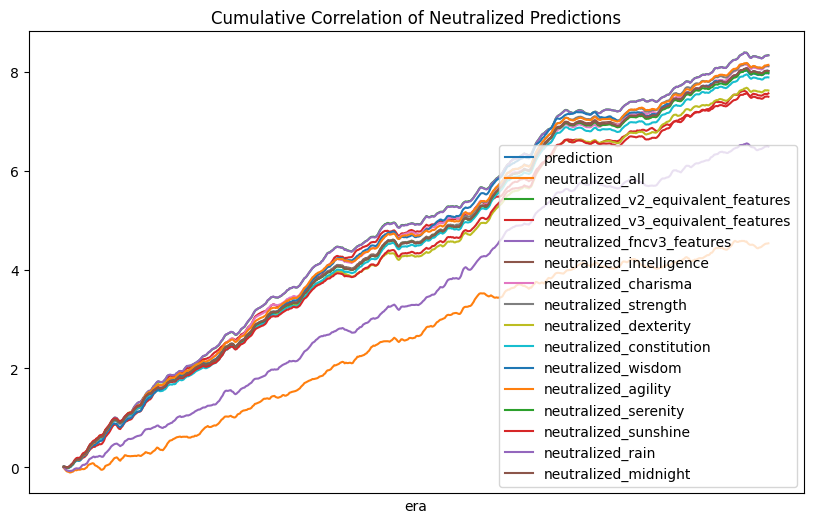

In [18]:
# neutralize preds against each group
for group in groups:
    neutral_feature_subset = list(subgroups["small"][group])
    neutralized = validation.groupby("era", group_keys=True).apply(
        lambda d: neutralize(d[["prediction"]], d[neutral_feature_subset])
    ).reset_index().set_index("id")
    validation[f"neutralized_{group}"] = neutralized["prediction"]

group_neutral_cols = ["prediction"] + [f"neutralized_{group}" for group in groups]
group_neutral_corr = validation.groupby("era").apply(
    lambda d: numerai_corr(d[group_neutral_cols], d["target"])
)
group_neutral_cumsum = group_neutral_corr.cumsum()

group_neutral_cumsum.plot(
  title="Cumulative Correlation of Neutralized Predictions",
  figsize=(10, 6),
  xticks=[]
)

Заметно, что нейтрализация некоторых групп улучшает метрику `CORR`, в то время как другие группы, наоборот, ухудшают её. Можешь подумать, почему это могло бы происходить?

Давай проверим, сохраняется ли такая же закономерность для `MMC`:

v4.3/meta_model.parquet: 29.0MB [00:00, 43.6MB/s]                            


<Axes: title={'center': 'Cumulative MMC of Neutralized Predictions'}, xlabel='era'>

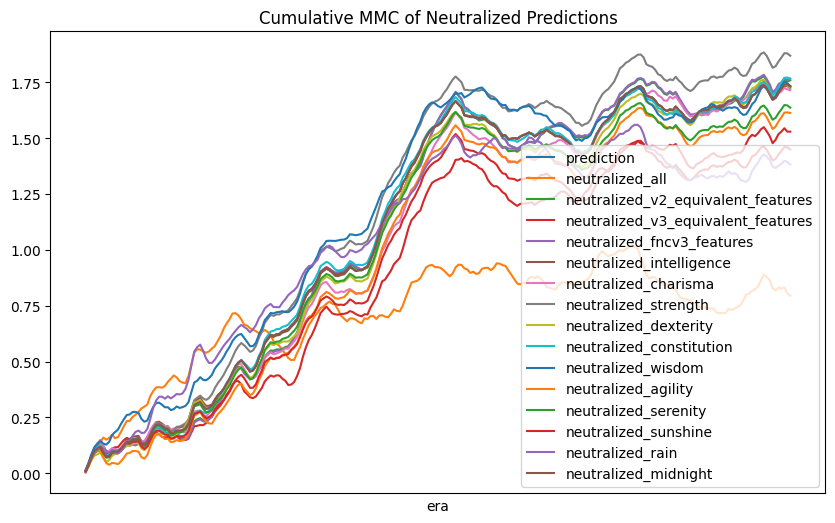

In [19]:
# Download and join in the meta_model for the validation eras
napi.download_dataset(f"v4.3/meta_model.parquet", round_num=842)
validation["meta_model"] = pd.read_parquet(
    f"v4.3/meta_model.parquet"
)["numerai_meta_model"]

# Compute the per-era mmc between our predictions, the meta model, and the target values
per_era_mmc = validation.dropna().groupby("era").apply(
    lambda x: correlation_contribution(
        x[group_neutral_cols], x["meta_model"], x["target"]
    )
)

cumsum_mmc = per_era_mmc.cumsum()

cumsum_mmc.plot(
  title="Cumulative MMC of Neutralized Predictions",
  figsize=(10, 6),
  xticks=[]
)

Возможно, самое интересное наблюдение заключается в том, что полная нейтрализация всех групп признаков в рамках набора `small` даёт худшие результаты по показателям `mean` и `sharpe` как для `CORR`, так и для `MMC`. Можешь предположить, почему это может происходить?

In [20]:
group_neutral_summary_metrics = {}
for col in group_neutral_cols:
    corr_mean = group_neutral_corr[col].mean()
    corr_std = group_neutral_corr[col].std()
    corr_sharpe = corr_mean / corr_std
    corr_rolling_max = group_neutral_cumsum[col].expanding(min_periods=1).max()
    corr_max_drawdown = (corr_rolling_max - group_neutral_cumsum[col]).max()
    mmc_mean = per_era_mmc[col].mean()
    mmc_std = per_era_mmc[col].std()
    mmc_sharpe = mmc_mean / mmc_std
    mmc_rolling_max = cumsum_mmc[col].expanding(min_periods=1).max()
    mmc_max_drawdown = (rolling_max - cumsum_mmc[col]).max()
    group_neutral_summary_metrics[col] = {
        "corr_mean": corr_mean,
        "mmc_mean": mmc_mean,
        "corr_std": corr_std,
        "mmc_std": mmc_std,
        "corr_sharpe": corr_sharpe,
        "mmc_sharpe": mmc_sharpe,
        "corr_max_drawdown": corr_max_drawdown,
        "mmc_max_drawdown": mmc_max_drawdown,
    }
pd.set_option('display.float_format', lambda x: '%f' % x)
pd.DataFrame(group_neutral_summary_metrics).T

,corr_mean,mmc_mean,corr_std,mmc_std,corr_sharpe,mmc_sharpe,corr_max_drawdown,mmc_max_drawdown
prediction,0.013090,0.007185,0.016569,0.016099,0.790003,0.446292,0.126650,5.899151
neutralized_all,0.007396,0.003297,0.015524,0.016393,0.476438,0.201132,0.199010,6.836043
neutralized_v2_equivalent_features,0.013609,0.007300,0.016663,0.016574,0.816762,0.440425,0.118531,5.876244
neutralized_v3_equivalent_features,0.012348,0.006345,0.016131,0.015979,0.765466,0.397069,0.109592,6.101615
neutralized_fncv3_features,0.013604,0.007329,0.016656,0.016579,0.816787,0.442062,0.119102,5.869087
neutralized_intelligence,0.013081,0.007154,0.016552,0.016053,0.790306,0.445663,0.127295,5.906493
neutralized_charisma,0.013246,0.007115,0.016228,0.016394,0.816244,0.433979,0.106901,5.916048
neutralized_strength,0.013248,0.007755,0.016554,0.016125,0.800308,0.480970,0.125132,5.761587
neutralized_dexterity,0.012443,0.007164,0.016527,0.016152,0.752879,0.443540,0.147327,5.904152
neutralized_constitution,0.012877,0.007324,0.016457,0.015992,0.782454,0.457960,0.130991,5.865611


Исходя из нашего простого анализа выше, похоже, что наилучший вариант с точки зрения производительности — это нейтрализация группы признаков `serenity` внутри набора `small` с полной степенью нейтрализации (100%).

Однако в ходе вашего исследования вы можете попробовать нейтрализовать разные подгруппы признаков в разных пропорциях и самостоятельно принять решение о том, как сбалансировать соотношение риска и выгоды от нейтрализации. Возможно, даже стоит рассмотреть включение процесса нейтрализации непосредственно в целевую функцию вашей модели вместо того, чтобы применять её постфактум к прогнозам, как мы сделали здесь.

Наконец, применение нейтрализации признаков к вашей модели остается исключительно вашим решением. Многие успешные модели вообще не используют нейтрализацию признаков!

## 4. Building a feature-neutral model (Создание модели, независимой от признаков)

Завершая данную тетрадь, давайте построим и загрузим новую модель, свободную от влияния признаков.

In [21]:
def predict_neutral(live_features: pd.DataFrame, _live_benchmark_models: pd.DataFrame = None) -> pd.DataFrame:
    # make predictions using all features
    predictions = pd.DataFrame(
        model.predict(live_features[small_features]),
        index=live_features.index,
        columns=["prediction"]
    )
    # neutralize predictions to a subset of features
    neutralized = neutralize(predictions, live_features[sm_serenity_feats])
    return neutralized.rank(pct=True)

In [22]:
# Quick test
napi.download_dataset(f"{DATA_VERSION}/live.parquet")
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=small_features)
predict_neutral(live_features)

v5.0/live.parquet: 8.35MB [00:00, 23.8MB/s]                            


,prediction
id,
n00245baeaa40ddd,0.535672
n003ba086e3f6948,0.987082
n003dcdc26b7fe93,0.564739
n004fa0bd6817c1a,0.521433
n0068348d5fb7103,0.697299
...,...
nffbe1f480d9c776,0.112889
nffda609caed3f75,0.872137
nffdb673dc376918,0.477246


In [ ]:
# Use the cloudpickle library to serialize your function and its dependencies
import cloudpickle
p = cloudpickle.dumps(predict_neutral)
with open("feature_neutralization.pkl", "wb") as f:
    f.write(p)

In [ ]:
# Download file if running in Google Colab
try:
    from google.colab import files
    files.download('feature_neutralization.pkl')
except:
    pass